In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, multivariate_normal  
from simulator import simulate

LOAD PRIOR CODE FROM VANILLA ABC

In [ ]:
infected_df = pd.read_csv("data/infected_timeseries.csv")
rewire_df = pd.read_csv("data/rewiring_timeseries.csv")
degree_df = pd.read_csv("data/final_degree_histograms.csv")

inf_wide = infected_df.pivot(index="time", columns="replicate_id", values="infected_fraction")
rew_wide = rewire_df.pivot(index="time", columns="replicate_id", values="rewire_count")

N_REPS = inf_wide.shape[1]
T = inf_wide.shape[0] - 1


      replicate_id  degree  count
0                0       0      0
1                0       1      0
2                0       2      0
3                0       3      0
4                0       4      4
...            ...     ...    ...
1235            39      26      0
1236            39      27      0
1237            39      28      0
1238            39      29      0
1239            39      30      0

[1240 rows x 3 columns]


In [5]:
# ── Compute_summary_stats ───

def compute_summary_stats(inf_wide, rew_wide, deg_df):
    """
    Compute the 7-statistic summary vector used for ABC.

    Statistics chosen after CV filtering and within/cross-source correlation analysis:
    Infection : peak_height, auc, growth_rate, time_to_peak
    Rewiring  : total_rewires, rew_inf_ratio
    Degree    : var_degree

    rew_inf_ratio = mean(peak_rewire_count_per_rep) / (mean_peak_infected_fraction * 200)
    This normalises rewiring intensity by epidemic size, capturing the rho/beta interaction.
    Verified comparable between observed and simulated data: s_obs sits at the 36th percentile
    of the prior-predictive distribution (confirmed in pilot analysis).
    """
    # Infection
    peak_height  = inf_wide.max(axis=0).mean()
    time_to_peak = inf_wide.idxmax(axis=0).mean()
    auc          = inf_wide.sum(axis=0).mean()

    def _growth(col):
        early = col.iloc[1:8].values
        early = np.where(early <= 0, 1e-6, early)
        return np.polyfit(np.arange(len(early)), np.log(early), 1)[0]

    growth_rate = inf_wide.apply(_growth, axis=0).mean()

    # Rewiring
    total_rewires = rew_wide.sum(axis=0).mean()
    peak_rewires  = rew_wide.max(axis=0).mean()
    rew_inf_ratio = peak_rewires / (peak_height * 200)
    

    # Degree
    def _var_degree(grp):
        degrees = grp["degree"].values
        counts  = grp["count"].values
        mean_d  = np.average(degrees, weights=counts)
        return np.average((degrees - mean_d)**2, weights=counts)

    var_degree = deg_df.groupby(
        "replicate_id", group_keys=False
    ).apply(lambda g: pd.Series({"v": _var_degree(g)}), include_groups=False)["v"].mean()

    return {
        "peak_height":   peak_height,
        "auc":           auc,
        "growth_rate":   growth_rate,
        "time_to_peak":  time_to_peak,
        "total_rewires": total_rewires,
        "rew_inf_ratio": rew_inf_ratio,
        "var_degree":    var_degree,
    }


# Compute s_obs 
s_obs = compute_summary_stats(inf_wide, rew_wide, degree_df)

print("Observed summary statistics (s_obs):")
for k, v in s_obs.items():
    print(f"  {k:<18}: {v:.5f}")

Observed summary statistics (s_obs):
  peak_height       : 0.65712
  auc               : 11.39900
  growth_rate       : 0.37520
  time_to_peak      : 8.75000
  total_rewires     : 545.15000
  rew_inf_ratio     : 0.74662
  var_degree        : 10.34102


In [6]:
PRIOR = {
    "beta":  (0.05, 0.50),
    "gamma": (0.02, 0.20),
    "rho":   (0.00, 0.80),
}

def sample_prior(rng):
    beta  = rng.uniform(*PRIOR["beta"])
    gamma = rng.uniform(*PRIOR["gamma"])
    rho   = rng.uniform(*PRIOR["rho"])
    return beta, gamma, rho

In [7]:
REPS_PER_DRAW = 5

def simulate_summary(beta, gamma, rho, n_reps, rng):
    """
    Run n_reps simulations at (beta, gamma, rho) and return the
    averaged 6-statistic summary vector.
    """
    inf_cols = {}
    rew_cols = {}
    deg_rows = []

    for rep in range(n_reps):
        inf_frac, rew_counts, deg_hist = simulate(
            beta=beta, gamma=gamma, rho=rho, rng=rng
        )
        inf_cols[rep] = inf_frac
        rew_cols[rep] = rew_counts
        for d, c in enumerate(deg_hist):
            deg_rows.append({"replicate_id": rep, "degree": d, "count": int(c)})

    inf_w = pd.DataFrame(inf_cols)
    rew_w = pd.DataFrame(rew_cols)
    deg_d = pd.DataFrame(deg_rows)

    return compute_summary_stats(inf_w, rew_w, deg_d)

In [8]:
# Distance Function 

STAT_NAMES = list(s_obs.keys())
# ['peak_height', 'auc', 'growth_rate', 'time_to_peak',
#  'total_rewires', 'rew_inf_ratio', 'var_degree']

def normalized_distance(s_sim, s_obs_dict, sigma):
    """
    Normalized Euclidean distance between two summary vectors.

    Each component (s_sim[k] - s_obs[k]) is divided by sigma[k],
    the prior-predictive standard deviation of statistic k.
    This ensures all 7 statistics contribute equally to the distance
    regardless of their original scale.

    Parameters
    ----------
    s_sim     : dict,  simulated summary statistics
    s_obs_dict: dict,  observed summary statistics (s_obs)
    sigma     : dict,  normalizing constants (prior-predictive std per statistic)
    """
    d_sq = 0.0
    for k in STAT_NAMES:
        if sigma[k] > 0:
            d_sq += ((s_sim[k] - s_obs_dict[k]) / sigma[k]) ** 2
    return np.sqrt(d_sq)

ABC-SMC

In [17]:
def estimate_sigma(n_draws, n_reps, rng):
    sims = []

    for _ in range(n_draws):
        beta, gamma, rho = sample_prior(rng)
        s_sim = simulate_summary(beta, gamma, rho, n_reps=n_reps, rng=rng)
        sims.append(s_sim)

    sims_df = pd.DataFrame(sims)
    sigma = sims_df.std(axis=0, ddof=1).to_dict()
    return sigma, sims_df

rng = np.random.default_rng(42)
sigma, prior_pred_df = estimate_sigma(n_draws=300, n_reps=REPS_PER_DRAW, rng=rng)

{'peak_height': 0.2341216648855566,
 'auc': 10.041906936060359,
 'growth_rate': 0.12205363504271163,
 'time_to_peak': 4.401611137073183,
 'total_rewires': 316.3446622446121,
 'rew_inf_ratio': 1.0797158617253382,
 'var_degree': 2.7830643981940555}

In [18]:
def in_prior_support(theta):
    beta, gamma, rho = theta
    return (
        PRIOR["beta"][0]  <= beta  <= PRIOR["beta"][1] and
        PRIOR["gamma"][0] <= gamma <= PRIOR["gamma"][1] and
        PRIOR["rho"][0]   <= rho   <= PRIOR["rho"][1]
    )

In [19]:
def weighted_mean_and_cov(particles, weights):
    particles = np.asarray(particles)
    weights = np.asarray(weights)
    mean = np.average(particles, axis=0, weights=weights)

    centered = particles - mean
    cov = np.einsum("i,ij,ik->jk", weights, centered, centered)
    return mean, cov

In [59]:
def abc_smc(n_particles, eps_schedule, n_reps, sigma, rng, max_tries_per_round=200000):
    populations = []
    all_distances = []

    # Round 0: rejection ABC
    particles, distances = [], []
    n_tries = 0

    while len(particles) < n_particles:
        n_tries += 1
        theta = sample_prior(rng)
        s_sim = simulate_summary(*theta, n_reps=n_reps, rng=rng)
        d = normalized_distance(s_sim, s_obs, sigma)

        if d <= eps_schedule[0]:
            particles.append(theta)
            distances.append(d)

        if n_tries >= max_tries_per_round and len(particles) < n_particles:
            raise RuntimeError(
                f"Round 0 could not fill {n_particles} particles. "
                f"Accepted {len(particles)} after {n_tries} tries. "
                f"eps={eps_schedule[0]:.4f}"
            )

    particles = np.array(particles)
    distances = np.array(distances)
    weights = np.ones(n_particles) / n_particles

    ess = 1.0 / np.sum(weights**2)
    acc_rate = len(particles) / n_tries

    populations.append({
        "particles": particles,
        "weights": weights,
        "distances": distances,
        "epsilon": eps_schedule[0],
        "accept_rate": acc_rate,
        "ess": ess,
        "n_tries": n_tries
    })
    all_distances.append(distances)

    # Rounds 1+
    for t in range(1, len(eps_schedule)):
        prev_particles = populations[-1]["particles"]
        prev_weights   = populations[-1]["weights"]

        _, weighted_cov = weighted_mean_and_cov(prev_particles, prev_weights)

        # EDIT 1: smaller kernel than 2.0 * cov
        dim = prev_particles.shape[1]
        kernel_cov = 1.0 * weighted_cov + 1e-6 * np.eye(dim)

        mvn = multivariate_normal(mean=np.zeros(dim), cov=kernel_cov)

        new_particles, new_weights, new_distances = [], [], []
        n_tries = 0

        while len(new_particles) < n_particles:
            n_tries += 1

            if n_tries >= max_tries_per_round:
                raise RuntimeError(
                    f"Round {t} could not fill {n_particles} particles. "
                    f"Accepted {len(new_particles)} after {n_tries} tries. "
                    f"eps={eps_schedule[t]:.4f}"
                )

            idx      = rng.choice(len(prev_particles), p=prev_weights)
            ancestor = prev_particles[idx]

            theta = ancestor + rng.multivariate_normal(
                mean=np.zeros(dim), cov=kernel_cov
            )

            if not in_prior_support(theta):
                continue

            s_sim = simulate_summary(*theta, n_reps=n_reps, rng=rng)
            d     = normalized_distance(s_sim, s_obs, sigma)

            if d > eps_schedule[t]:
                continue

            diffs = theta - prev_particles
            kernel_vals = mvn.pdf(diffs)
            denom = np.dot(prev_weights, kernel_vals)

            # EDIT 2: safety check for denominator
            if (not np.isfinite(denom)) or (denom <= 1e-300):
                continue

            # EDIT 3: keep this only if prior is uniform on a box
            w = 1.0 / denom

            new_particles.append(theta)
            new_weights.append(w)
            new_distances.append(d)

        new_particles  = np.array(new_particles)
        new_weights    = np.array(new_weights)
        new_distances  = np.array(new_distances)

        # EDIT 4: normalize safely
        wsum = np.sum(new_weights)
        if (not np.isfinite(wsum)) or (wsum <= 0):
            raise RuntimeError(f"Invalid weight sum in round {t}: {wsum}")

        new_weights = new_weights / wsum

        ess = 1.0 / np.sum(new_weights**2)
        acc_rate = len(new_particles) / n_tries

        populations.append({
            "particles": new_particles,
            "weights": new_weights,
            "distances": new_distances,
            "epsilon": eps_schedule[t],
            "accept_rate": acc_rate,
            "ess": ess,
            "n_tries": n_tries
        })
        all_distances.append(new_distances)

    return populations, all_distances

In [ ]:
rng = np.random.default_rng(42)

eps_schedule = [5.0, 3.5, 2.5, 1.8, 1.0, 0.5]

populations, all_distances = abc_smc(
    n_particles=500,
    eps_schedule=eps_schedule,
    n_reps=REPS_PER_DRAW,
    sigma=sigma,
    rng=rng
)

Analysis

In [ ]:
final_pop = populations[-1]
theta_smc = final_pop["particles"]  # shape (N, 3)
w_smc = final_pop["weights"]
d_smc = final_pop["distances"]
ess_smc = final_pop["ess"]

smc_df = pd.DataFrame(theta_smc, columns=["beta", "gamma", "rho"])
smc_df["weight"] = w_smc
smc_df["distance"] = d_smc
smc_df["ess"] = ess_smc
smc_df.head()

<bound method NDFrame.head of          beta     gamma       rho    weight  distance         ess
0    0.152503  0.084964  0.282227  0.001869  0.248718  489.116725
1    0.149310  0.104392  0.290702  0.002220  0.308802  489.116725
2    0.190284  0.100834  0.344624  0.001718  0.412050  489.116725
3    0.160678  0.096993  0.280698  0.001842  0.385192  489.116725
4    0.203416  0.081739  0.338511  0.001679  0.391096  489.116725
..        ...       ...       ...       ...       ...         ...
495  0.139040  0.089643  0.292191  0.002255  0.311542  489.116725
496  0.184542  0.086861  0.322218  0.001640  0.423729  489.116725
497  0.199743  0.106890  0.335796  0.001753  0.486753  489.116725
498  0.149985  0.074408  0.314303  0.002181  0.284171  489.116725
499  0.148955  0.076621  0.262083  0.001999  0.440199  489.116725

[500 rows x 6 columns]>

In [85]:
vanilla_abc = pd.read_csv("abc_results_full.csv")
vanilla_df = pd.DataFrame(vanilla_abc, columns=["beta", "gamma", "rho","distance"])
vanilla_df["weight"] = 1 / len(vanilla_df)

vanilla_df.head()

,beta,gamma,rho,distance,weight
0,0.227893,0.098172,0.363545,0.595883,0.002519
1,0.192283,0.123144,0.384364,0.592783,0.002519
2,0.182756,0.076239,0.400427,0.517805,0.002519
3,0.164399,0.057989,0.301401,0.620225,0.002519
4,0.162855,0.117460,0.278604,0.628982,0.002519


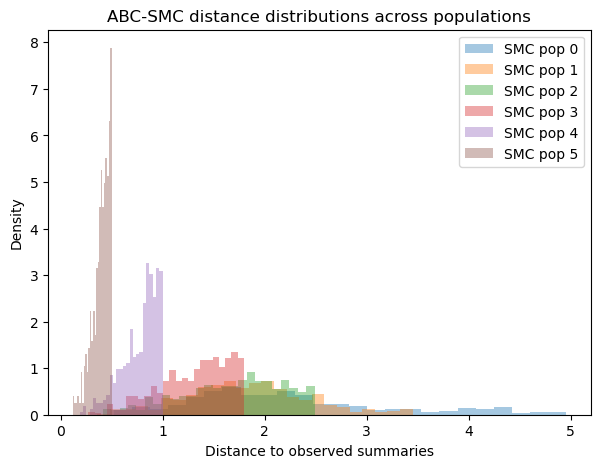

In [88]:
plt.figure(figsize=(7,5))
for t, dist in enumerate(all_distances):
    plt.hist(dist, bins=25, alpha=0.4, density=True, label=f"SMC pop {t}")
plt.xlabel("Distance to observed summaries")
plt.ylabel("Density")
plt.title("ABC-SMC distance distributions across populations")
plt.legend()
plt.show()

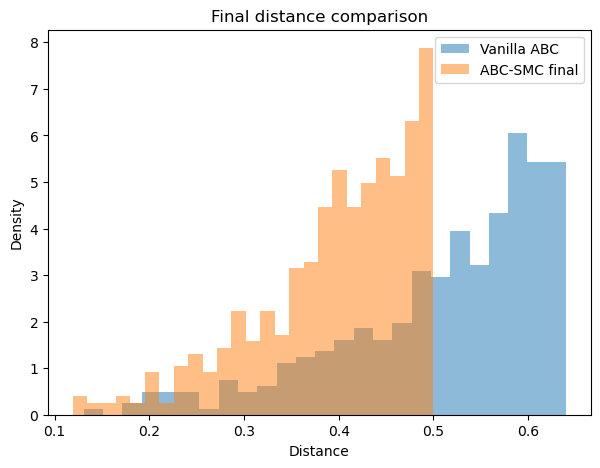

In [89]:
plt.figure(figsize=(7,5))
plt.hist(vanilla_df["distance"], bins=25, alpha=0.5, density=True, label="Vanilla ABC")
plt.hist(smc_df["distance"], bins=25, alpha=0.5, density=True, label="ABC-SMC final")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.title("Final distance comparison")
plt.legend()
plt.show()

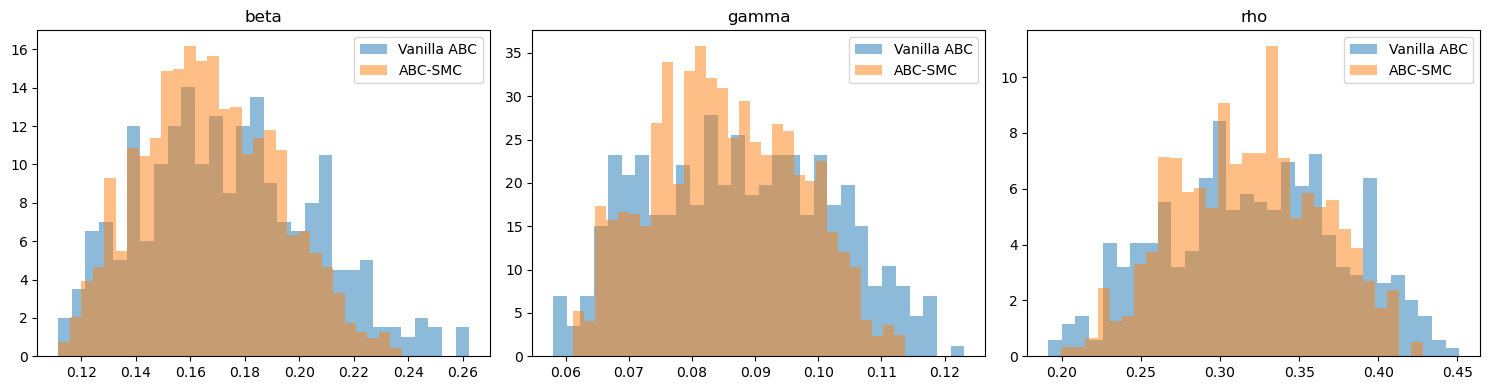

In [90]:
params = ["beta", "gamma", "rho"]

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, p in enumerate(params):
    axes[i].hist(vanilla_df[p], bins=30, density=True, alpha=0.5, label="Vanilla ABC")
    axes[i].hist(smc_df[p], bins=30, weights=smc_df["weight"], density=True, alpha=0.5, label="ABC-SMC")
    axes[i].set_title(p)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [91]:
import numpy as np

def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)

    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.asarray(sample_weight)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cdf = np.cumsum(sample_weight)
    cdf = cdf / cdf[-1]

    return np.interp(quantiles, cdf, values)

for p in params:
    # vanilla
    v_mean = vanilla_df[p].mean()
    v_q = vanilla_df[p].quantile([0.025, 0.5, 0.975]).values

    # smc
    s_mean = np.average(smc_df[p], weights=smc_df["weight"])
    s_q = weighted_quantile(smc_df[p], [0.025, 0.5, 0.975], sample_weight=smc_df["weight"])

    print(f"{p}")
    print(f"  Vanilla ABC   mean={v_mean:.4f}, 95% CI=({v_q[0]:.4f}, {v_q[2]:.4f})")
    print(f"  ABC-SMC       mean={s_mean:.4f}, 95% CI=({s_q[0]:.4f}, {s_q[2]:.4f})")

beta
  Vanilla ABC   mean=0.1737, 95% CI=(0.1208, 0.2414)
  ABC-SMC       mean=0.1674, 95% CI=(0.1227, 0.2154)
gamma
  Vanilla ABC   mean=0.0875, 95% CI=(0.0632, 0.1159)
  ABC-SMC       mean=0.0854, 95% CI=(0.0652, 0.1064)
rho
  Vanilla ABC   mean=0.3212, 95% CI=(0.2148, 0.4205)
  ABC-SMC       mean=0.3177, 95% CI=(0.2280, 0.4037)


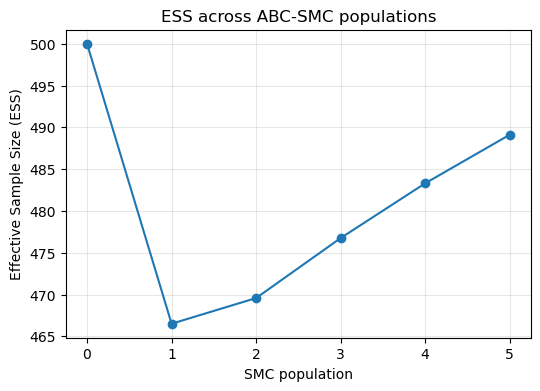

In [100]:
ess_df = pd.DataFrame({
    "population": range(len(populations)),
    "epsilon": [pop["epsilon"] for pop in populations],
    "ESS": [pop["ess"] for pop in populations],
    "accept_rate": [pop["accept_rate"] for pop in populations],
    "n_tries": [pop["n_tries"] for pop in populations]
})

plt.figure(figsize=(6, 4))
plt.plot(ess_df["population"], ess_df["ESS"], marker="o")
plt.xticks(ess_df["population"])
plt.xlabel("SMC population")
plt.ylabel("Effective Sample Size (ESS)")
plt.title("ESS across ABC-SMC populations")
plt.grid(True, alpha=0.3)
plt.show()


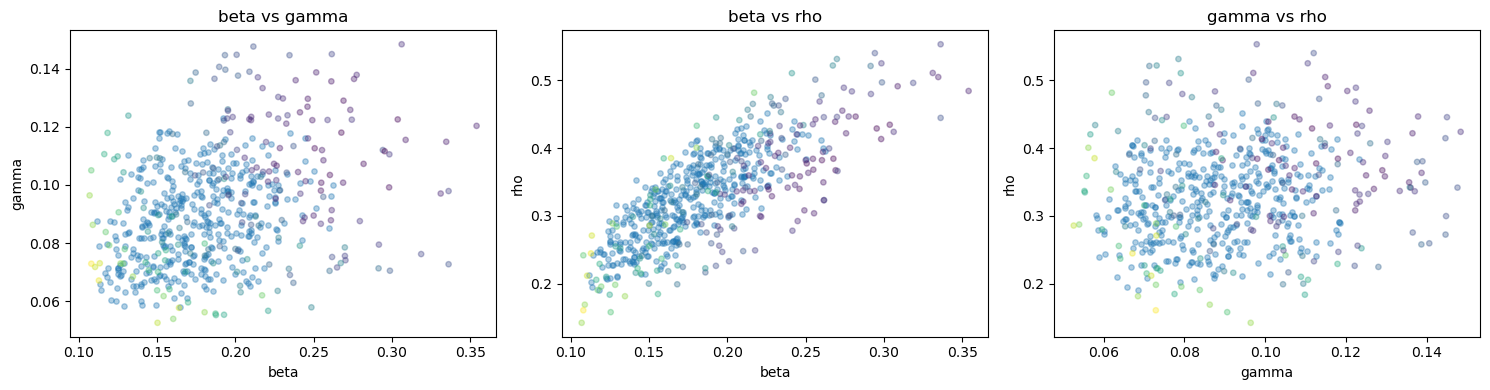

Vanilla ABC correlations
           beta     gamma       rho
beta   1.000000  0.323091  0.784544
gamma  0.323091  1.000000  0.180732
rho    0.784544  0.180732  1.000000

ABC-SMC correlations (unweighted rough check)
          beta     gamma       rho
beta   1.00000  0.230510  0.788240
gamma  0.23051  1.000000  0.062949
rho    0.78824  0.062949  1.000000
Vanilla ABC correlations
           beta     gamma       rho
beta   1.000000  0.323091  0.784544
gamma  0.323091  1.000000  0.180732
rho    0.784544  0.180732  1.000000

ABC-SMC correlations (unweighted rough check)
          beta     gamma       rho
beta   1.00000  0.230510  0.788240
gamma  0.23051  1.000000  0.062949
rho    0.78824  0.062949  1.000000


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

pairs = [("beta", "gamma"), ("beta", "rho"), ("gamma", "rho")]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(vanilla_df[x], vanilla_df[y], alpha=0.35, s=15, label="Vanilla ABC")
    ax.scatter(smc_df[x], smc_df[y], alpha=0.35, s=15,
               c=smc_df["weight"], cmap="viridis", label="ABC-SMC")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

print("Vanilla ABC correlations")
print(vanilla_df[params].corr())

print("\nABC-SMC correlations (unweighted rough check)")
print(smc_df[params].corr())

print("Vanilla ABC correlations")
print(vanilla_df[params].corr())

print("\nABC-SMC correlations (unweighted rough check)")
print(smc_df[params].corr())

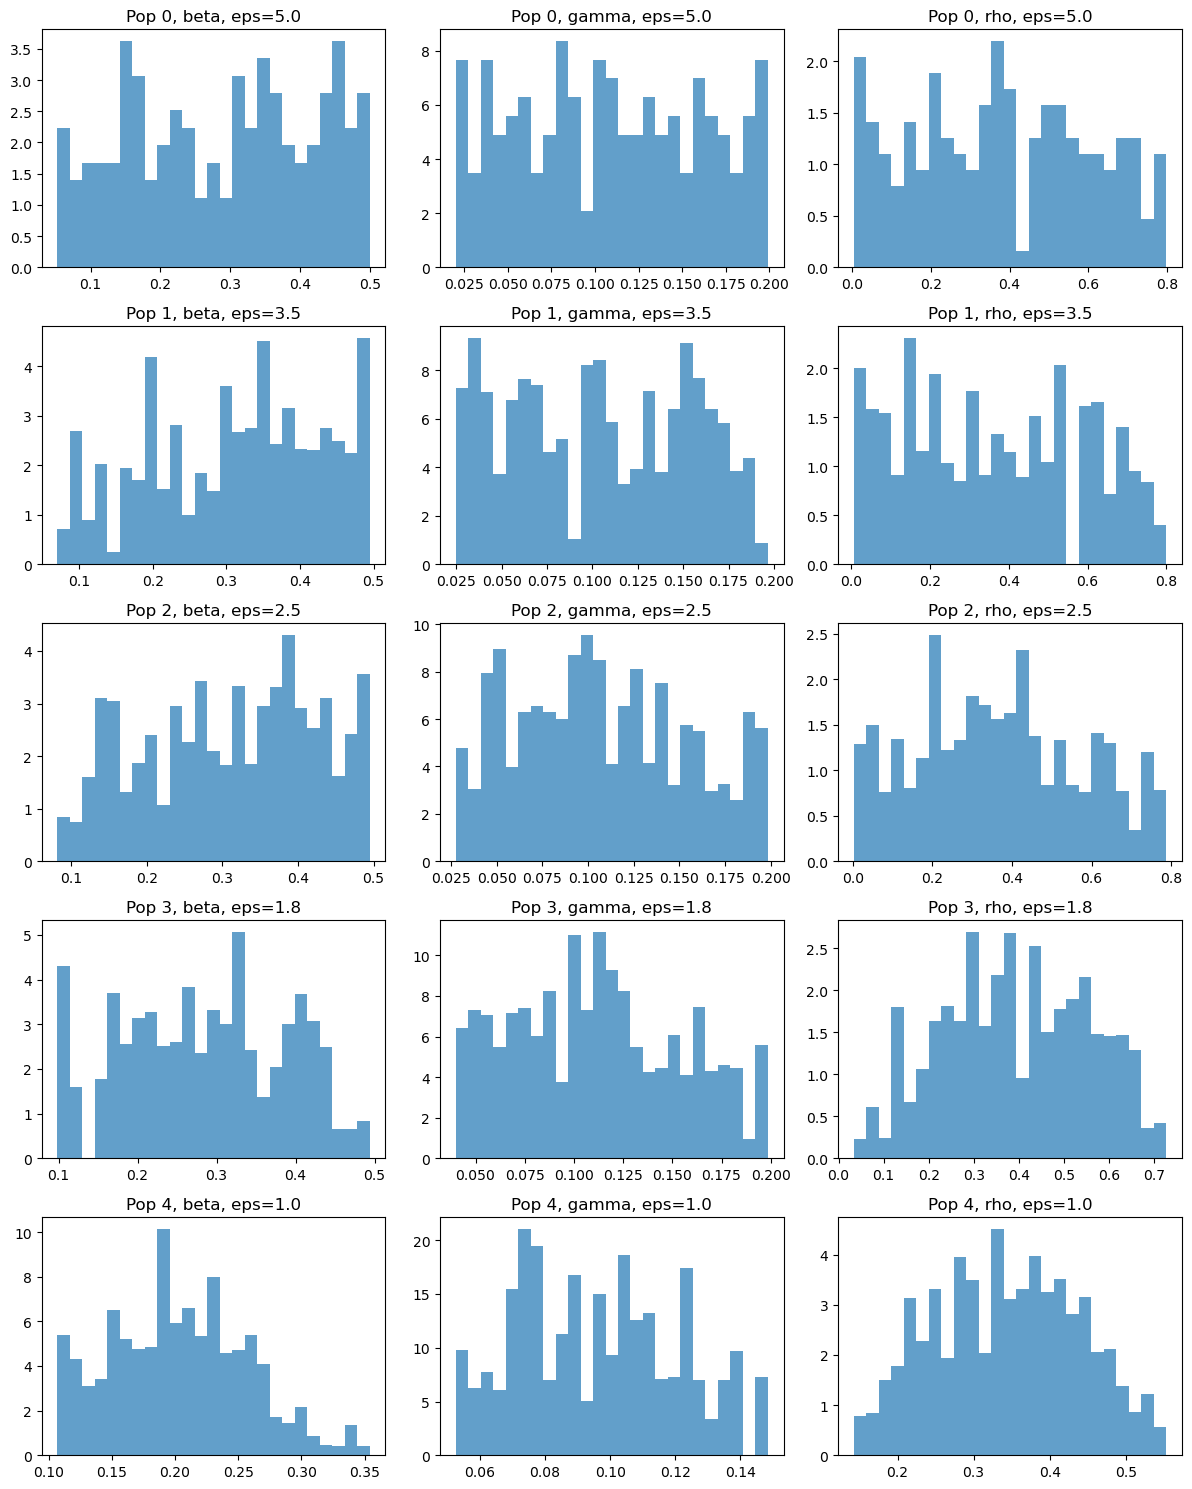

In [53]:
fig, axes = plt.subplots(len(populations), 3, figsize=(12, 3*len(populations)))

for t, pop in enumerate(populations):
    pop_df = pd.DataFrame(pop["particles"], columns=["beta", "gamma", "rho"])
    pop_w = pop["weights"]

    for j, p in enumerate(params):
        axes[t, j].hist(pop_df[p], bins=25, weights=pop_w, density=True, alpha=0.7)
        axes[t, j].set_title(f"Pop {t}, {p}, eps={pop['epsilon']}")

plt.tight_layout()
plt.show()

In [54]:
def posterior_predictive_summaries(theta_samples, rng, n_reps):
    sims = []
    for theta in theta_samples:
        beta, gamma, rho = theta
        s_sim = simulate_summary(beta, gamma, rho, n_reps=n_reps, rng=rng)
        sims.append(s_sim)
    return pd.DataFrame(sims)

rng = np.random.default_rng(123)

# sample a subset if too large
theta_v_sub = vanilla_df[["beta", "gamma", "rho"]].sample(
    n=min(100, len(vanilla_df)), random_state=123
).values

pp_vanilla = posterior_predictive_summaries(theta_v_sub, rng, n_reps=REPS_PER_DRAW)

idx = rng.choice(len(smc_df), size=min(100, len(smc_df)), replace=True, p=smc_df["weight"])
theta_s_sub = smc_df.loc[idx, ["beta", "gamma", "rho"]].values

pp_smc = posterior_predictive_summaries(theta_s_sub, rng, n_reps=REPS_PER_DRAW)

summary_names = list(s_obs.keys())

fig, axes = plt.subplots(len(summary_names), 2, figsize=(10, 4*len(summary_names)))

for i, sname in enumerate(summary_names):
    axes[i, 0].hist(pp_vanilla[sname], bins=25, alpha=0.7)
    axes[i, 0].axvline(s_obs[sname], linestyle="--")
    axes[i, 0].set_title(f"Vanilla ABC PPC: {sname}")

    axes[i, 1].hist(pp_smc[sname], bins=25, alpha=0.7)
    axes[i, 1].axvline(s_obs[sname], linestyle="--")
    axes[i, 1].set_title(f"ABC-SMC PPC: {sname}")

plt.tight_layout()
plt.show()